In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv('./cleaned_dataset.csv')

In [4]:
df.head()
df_copy = df.copy()

In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      500 non-null    object 
 1   job_description  500 non-null    object 
 2   match_score      500 non-null    float64
 3   match_label      500 non-null    object 
 4   resume_text_len  500 non-null    int64  
 5   jd_length        500 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 23.6+ KB


In [6]:
# Clean up values first (optional but recommended)
df_copy['match_label'] = df_copy['match_label'].str.strip().str.lower()

In [7]:
df_copy.columns

Index(['resume_text', 'job_description', 'match_score', 'match_label',
       'resume_text_len', 'jd_length'],
      dtype='object')

In [8]:
df_copy.head(10)

,resume_text,job_description,match_score,match_label,resume_text_len,jd_length
0,Name Kritika Shah Email kritika.shah55gmail.c...,Job Title FPA Analyst Company Amazon Locatio...,0.55,partial match,157,154
1,Name Arjun Verma Email arjun.verma70gmail.com...,Job Title Design Lead Company Paytm Location...,0.27,no match,173,159
2,Name Manish Bhatt Email manish.bhatt89gmail.c...,Job Title Security Analyst Company KPMG Loca...,0.46,partial match,162,150
3,Name Natasha Sharma Email natasha.sharma76gma...,Job Title Sales Director Company Ola Locatio...,0.09,no match,151,165
4,Name Kavya Agarwal Email kavya.agarwal75gmail...,Job Title Business Development Manager Compan...,0.66,partial match,166,164
5,Name Divya Bhatt Email divya.bhatt72gmail.com...,Job Title Senior Data Scientist Company EY L...,0.11,no match,165,158
6,Name Varun Naidu Email varun.naidu97gmail.com...,Job Title Investment Analyst Company upGrad ...,0.95,match,157,152
7,Name Vikram Singh Email vikram.singh43gmail.c...,Job Title Financial Analyst Company Zoho Loc...,0.17,no match,168,154
8,Name Ananya Joshi Email ananya.joshi19gmail.c...,Job Title Group Product Manager Company Zerod...,0.75,match,170,159
9,Name Rishabh Banerjee Email rishabh.banerjee7...,Job Title Recruiter Company Flipkart Locatio...,0.94,match,159,161


In [9]:
print("Loading BERT Model")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model Loaded!")
print(f"Model : all-MiniLM-L6-v2")
print(f"Parameters: 22.7M")
print(f"Embeddings Dimensions: 384")
print(f"Max Tokens: {model.max_seq_length}")

Loading BERT Model


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Loaded!
Model : all-MiniLM-L6-v2
Parameters: 22.7M
Embeddings Dimensions: 384
Max Tokens: 256


In [10]:
print("\n Generating resume text embeddings...")
resume_embeddings = model.encode(
    df_copy['resume_text'].to_list(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
    )

print("\n Generating job description embeddings...")
jd_embeddings = model.encode(
    df_copy['job_description'].to_list(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embbeddings shape: {resume_embeddings.shape}")
print(f"JD embeddings shape: {jd_embeddings.shape}")
print(f"Each text -> {resume_embeddings.shape[1]} - dimensional vector")




 Generating resume text embeddings...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


 Generating job description embeddings...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Resume embbeddings shape: (500, 384)
JD embeddings shape: (500, 384)
Each text -> 384 - dimensional vector


In [11]:
pair_similarities = list()
for i in range(len(resume_embeddings)):
    # Suppose resume_embeddings[i] and jd_embeddings[i] are 1D vectors
    sim = cosine_similarity(resume_embeddings[i].reshape(1, -1), jd_embeddings[i].reshape(1, -1))[0][0]
    pair_similarities.append(sim)
    
df_copy['bert_similarity'] = pair_similarities

print("Cosine Similarity computed for all pairs.")
df_copy[['match_label','match_score', 'bert_similarity']].head(10)

Cosine Similarity computed for all pairs.


,match_label,match_score,bert_similarity
0,partial match,0.55,0.591054
1,no match,0.27,0.501551
2,partial match,0.46,0.492306
3,no match,0.09,0.371672
4,partial match,0.66,0.406941
5,no match,0.11,0.422523
6,match,0.95,0.614832
7,no match,0.17,0.474831
8,match,0.75,0.634789
9,match,0.94,0.665541


In [13]:
mae = mean_absolute_error(df_copy['match_score'], df_copy['bert_similarity'])
rmse = np.sqrt(mean_squared_error(df_copy['match_score'], df_copy['bert_similarity']))

print("Base BERT Model Performance (before fine-tunning)")
print("=" * 50)
print(f"MAE: {mae:.4f} (lower is better)")
print(f"RMSE : {rmse:.4f} (lower is better)")


Base BERT Model Performance (before fine-tunning)
MAE: 0.2083 (lower is better)
RMSE : 0.2390 (lower is better)


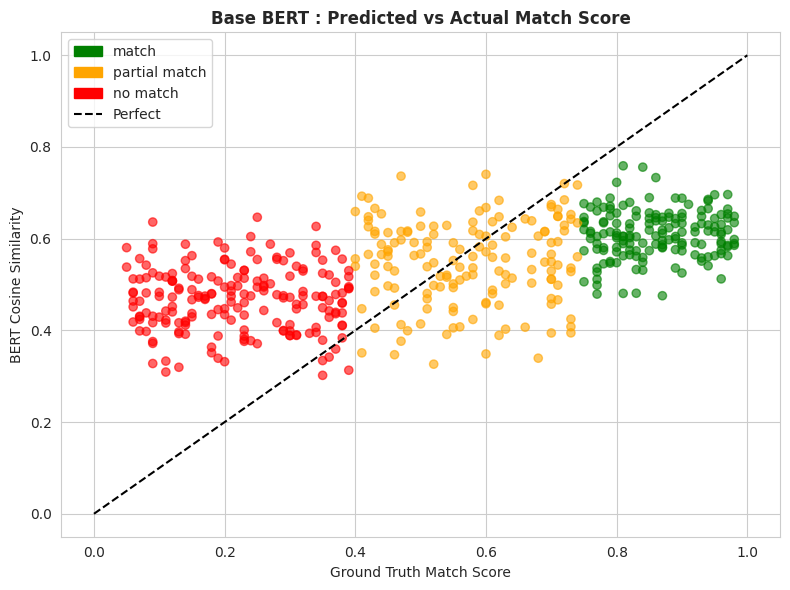

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.figure(figsize=(8,6))

# Make sure the mapping keys match your actual column values
color = df_copy['match_label'].map({
    'no match': 'red',
    'partial match': 'orange',
    'match': 'green'
}).fillna('gray')   # fallback for unexpected labels

plt.scatter(df_copy['match_score'], df_copy['bert_similarity'], 
            c=color, alpha=0.6)

plt.plot([0, 1], [0, 1], 'k--', label='Perfect Prediction')
plt.xlabel('Ground Truth Match Score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT : Predicted vs Actual Match Score', fontweight='bold')

# Legend
plt.legend(handles=[
    Patch(color='green', label='match'),
    Patch(color='orange', label='partial match'),
    Patch(color='red', label='no match'),
    plt.Line2D([0], [0], color='black', linestyle='--', label='Perfect')
])

plt.tight_layout()
plt.show()


Text(0, 0.5, 'Cosine_Similarity')

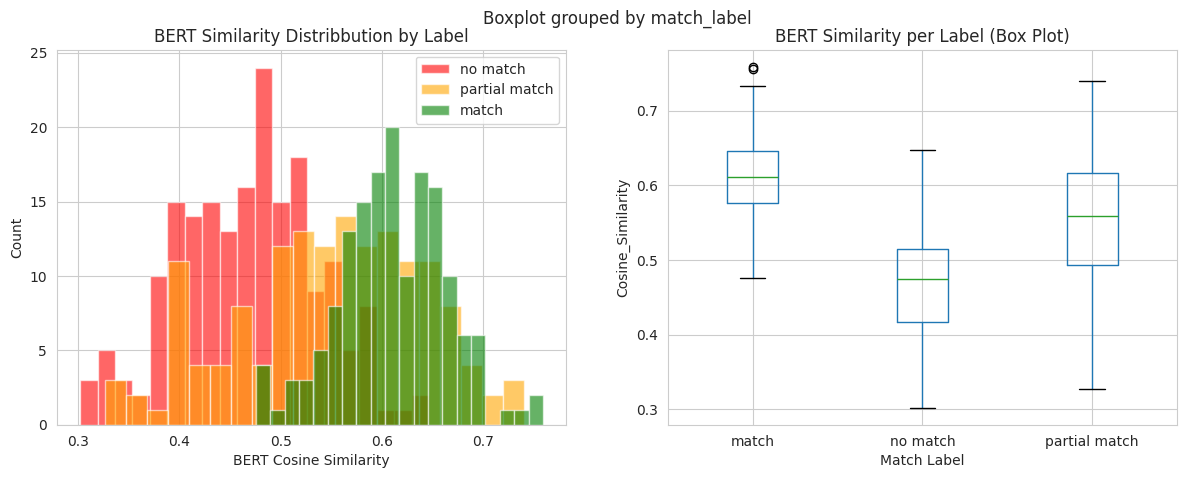

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [('no match', 'red'), ('partial match', 'orange'), ('match', 'green')]:
    subset = df_copy[df_copy['match_label'] == label]['bert_similarity']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color)
    
axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribbution by Label')
axes[0].legend()


df_copy.boxplot(column='bert_similarity', by='match_label', positions=[0, 1, 2], ax=axes[1])
axes[1].set_title('BERT Similarity per Label (Box Plot)')
axes[1].set_xlabel('Match Label')
axes[1].set_ylabel('Cosine_Similarity')

In [16]:
import pickle

with open('resume_embedding.pkl', 'wb') as f:
    pickle.dump({
        'resume_embeddings' : resume_embeddings,
        'jd_embeddings' : jd_embeddings,
        'match_scores' : df_copy['match_score'].to_list(),
        'match_labels' : df_copy['match_label'].to_list()
    }, f)
    
    print('Saved : resume embeddings.pkl')
    print(f'resume_embeddings : {resume_embeddings.shape}')
    print(f'jd_embeddings: {jd_embeddings.shape}')
    print()
    print("These will used for fine-tunning.")

Saved : resume embeddings.pkl
resume_embeddings : (500, 384)
jd_embeddings: (500, 384)

These will used for fine-tunning.
